In [1]:
# 导入项目所需的主要工具
# Import the main libraries required for the project
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# 如果 CUDA 可用就使用 GPU，否则自动使用 CPU
# Use the GPU when CUDA is available; otherwise use the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", device)

# 显示当前 GPU 名称，方便 Demo 时证明代码确实连接了 GPU
# Display the GPU name as evidence that the notebook is using CUDA
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
Device: cuda
GPU name: Tesla T4


# COMP3710 Lab 1 — Sierpiński Carpet

This notebook implements and analyses a GPU-accelerated Sierpiński Carpet using vectorised PyTorch tensor operations.

## Project Goals

- Generate the Sierpiński Carpet using a pixel-grid and ternary-coordinate algorithm.
- Process all image coordinates in parallel using PyTorch.
- Compare different recursion depths.
- Create multiple colour visualisations.
- Estimate the box-counting dimension.
- Compare the estimated dimension with the theoretical value.
- Compare CPU and GPU execution times.

Recursion depth: 5
Image size: (243, 243)
Occupied pixels: 32768
Expected occupied pixels: 32768
Tensor device: cuda:0


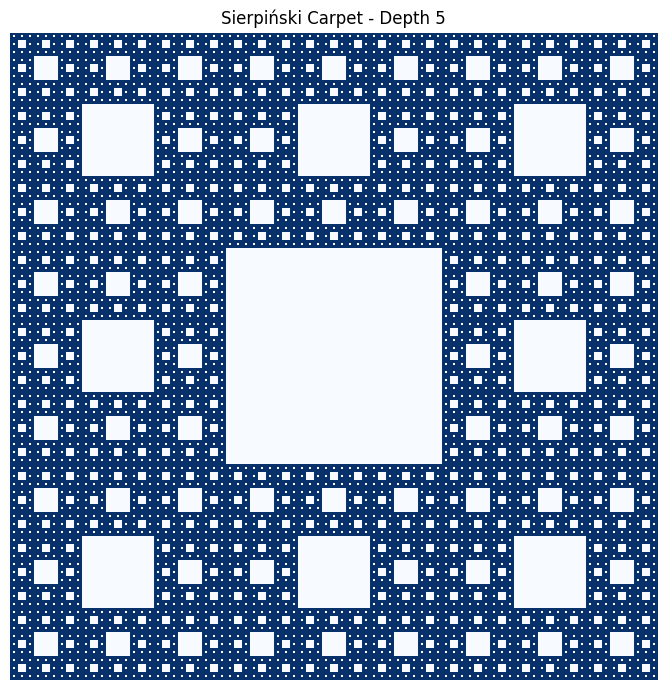

In [2]:
# 生成 Sierpiński Carpet
# Generate a Sierpiński Carpet
def generate_sierpinski_carpet(depth, target_device):
    """
    Generate a Sierpiński Carpet using ternary-coordinate testing.

    depth: recursion depth
    target_device: CPU or GPU device
    """

    # 深度 d 对应的图像边长为 3^d
    # At depth d, the image width and height are 3^d
    size = 3 ** depth

    # 在指定设备上创建所有横纵坐标
    # Create all horizontal and vertical coordinates on the selected device
    coordinates = torch.arange(
        size,
        device=target_device,
        dtype=torch.int64
    )

    y, x = torch.meshgrid(
        coordinates,
        coordinates,
        indexing="ij"
    )

    # True 表示保留该像素，False 表示删除该像素
    # True means the pixel remains; False means it is removed
    carpet = torch.ones(
        (size, size),
        dtype=torch.bool,
        device=target_device
    )

    # 创建坐标副本，用于逐层检查三进制数字
    # Copy the coordinates for checking ternary digits at each level
    check_x = x.clone()
    check_y = y.clone()

    # 这里只循环递归层数，不逐个循环处理像素
    # This loop processes recursion levels, not individual pixels
    for level in range(depth):

        # 如果 x 和 y 当前的三进制位都等于 1，
        # 该像素位于某一层的中央正方形中，需要删除
        # If the current ternary digits of both x and y equal 1,
        # the pixel is inside a centre square and must be removed
        centre_square = (
            (check_x % 3 == 1) &
            (check_y % 3 == 1)
        )

        carpet = carpet & (~centre_square)

        # 删除已经检查过的最低三进制位
        # Remove the ternary digit that has already been checked
        check_x = check_x // 3
        check_y = check_y // 3

    return carpet


# 使用深度 5 生成分形
# Generate the fractal at recursion depth 5
depth = 5
carpet = generate_sierpinski_carpet(depth, device)

# 计算并验证保留像素的数量
# Count and verify the number of remaining pixels
occupied_pixels = int(carpet.sum().item())
expected_pixels = 8 ** depth

print("Recursion depth:", depth)
print("Image size:", tuple(carpet.shape))
print("Occupied pixels:", occupied_pixels)
print("Expected occupied pixels:", expected_pixels)
print("Tensor device:", carpet.device)

# 将结果移回 CPU，以便 Matplotlib 绘图
# Move the result to the CPU for Matplotlib
carpet_image = carpet.cpu().numpy()

plt.figure(figsize=(7, 7))
plt.imshow(
    carpet_image,
    cmap="Blues",
    origin="upper",
    interpolation="nearest"
)
plt.title(f"Sierpiński Carpet - Depth {depth}")
plt.axis("off")
plt.tight_layout()
plt.show()